# ML-10 — Content Action Playbook

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

In [1]:
# Setup — identical warehouse query + feature build as w06, condensed
from getpass import getpass
import os, duckdb, numpy as np, pandas as pd
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

HF_TOKEN = os.environ.get('HF_TOKEN') or getpass('Paste your HF token: ')
con = duckdb.connect()
con.execute(f"CREATE OR REPLACE SECRET hf (TYPE huggingface, TOKEN '{HF_TOKEN}')")
REL = 'hf://datasets/FlyRank/internship-warehouse'
tbl = f"read_parquet('{REL}/fact_content_daily_performance/**/*.parquet', hive_partitioning=true)"

raw = con.sql(f"""
    WITH bounds AS (SELECT MAX(report_date) AS max_d FROM {tbl}),
    decision AS (SELECT max_d - INTERVAL 30 DAY AS decision_date FROM bounds),
    prior AS (
        SELECT f.content_hash_id, ANY_VALUE(f.client_hash_id) AS client_hash_id,
            AVG(f.gsc_clicks) AS avg_daily_clicks_prior,
            AVG(f.gsc_avg_position) FILTER (WHERE f.gsc_avg_position > 0) AS avg_position_prior,
            COUNT(*) FILTER (WHERE f.gsc_clicks > 0) AS days_with_clicks_prior,
            SUM(f.sessions_ai) * 1.0 / NULLIF(SUM(f.sessions_organic + f.sessions_ai), 0) AS ai_share_prior,
            COUNT(*) AS n_days_prior
        FROM {tbl} f, decision d
        WHERE f.report_date >= d.decision_date - INTERVAL 90 DAY AND f.report_date < d.decision_date
        GROUP BY f.content_hash_id HAVING COUNT(*) >= 30
    ),
    future AS (
        SELECT f.content_hash_id, AVG(f.gsc_clicks) AS avg_daily_clicks_future
        FROM {tbl} f, decision d
        WHERE f.report_date >= d.decision_date AND f.report_date < d.decision_date + INTERVAL 30 DAY
        GROUP BY f.content_hash_id
    )
    SELECT p.*, fu.avg_daily_clicks_future FROM prior p JOIN future fu USING (content_hash_id)
""").df()

raw['avg_position_prior'] = raw['avg_position_prior'].fillna(100)
raw['no_ranking_data_prior'] = (raw['avg_position_prior'] == 100).astype(int)
raw['ai_share_prior'] = raw['ai_share_prior'].fillna(0)
raw['click_consistency_prior'] = raw['days_with_clicks_prior'] / raw['n_days_prior']
raw['is_declining_future'] = (
    (raw['avg_daily_clicks_future'] < 0.75 * raw['avg_daily_clicks_prior']) &
    (raw['avg_daily_clicks_prior'] >= 1.0)
).astype(int)

eligible = raw.loc[raw['avg_daily_clicks_prior'] >= 1.0].copy()
feature_cols = ['avg_daily_clicks_prior', 'avg_position_prior', 'click_consistency_prior', 'ai_share_prior', 'no_ranking_data_prior']
X, y, groups = eligible[feature_cols], eligible['is_declining_future'], eligible['client_hash_id']

gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
model = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced').fit(X.iloc[train_idx], y.iloc[train_idx])

queue = eligible.iloc[test_idx].copy()
queue['model_score'] = model.predict_proba(X.iloc[test_idx])[:, 1]
median_pos = eligible.loc[eligible.index[train_idx], 'avg_position_prior'].median()

Paste your HF token: ··········


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [2]:
def reason_code(row):
    codes = []
    if row['avg_position_prior'] > median_pos: codes.append('weak_position')
    if row['click_consistency_prior'] < 0.5: codes.append('inconsistent_visibility')
    if row['avg_daily_clicks_prior'] >= eligible['avg_daily_clicks_prior'].quantile(0.75): codes.append('high_value_page')
    return ','.join(codes) if codes else 'model_flagged_no_rule_match'

queue['reason_code'] = queue.apply(reason_code, axis=1)
queue['action'] = np.where(queue['model_score'] >= 0.7, 'review_priority_1',
                    np.where(queue['model_score'] >= 0.5, 'review_priority_2', 'monitor'))

ranked = queue.sort_values('model_score', ascending=False).reset_index(drop=True)
ranked['rank'] = ranked.index + 1
ranked[['rank','content_hash_id','model_score','action','reason_code']].head(20)

,rank,content_hash_id,model_score,action,reason_code
0,1,content_e7c79604f38f86f5,0.970,review_priority_1,high_value_page
1,2,content_1c00cf3d4bbf2176,0.965,review_priority_1,"weak_position,inconsistent_visibility,high_val..."
2,3,content_6478f978b79a1b49,0.960,review_priority_1,high_value_page
3,4,content_4d0d79fc12632ef8,0.955,review_priority_1,high_value_page
4,5,content_3b8638bf882420e3,0.955,review_priority_1,high_value_page
5,6,content_7172a7fad43f0998,0.945,review_priority_1,high_value_page
6,7,content_29c4a3831609805d,0.945,review_priority_1,high_value_page
7,8,content_90e631c88cc0cf9e,0.940,review_priority_1,high_value_page
8,9,content_62850cc56d45a7cf,0.940,review_priority_1,high_value_page
9,10,content_dbbde91a0db0f0e3,0.935,review_priority_1,high_value_page


## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

Intended for: a content team's weekly triage — surfacing which of many pages (out of the ~1.9%
that clear the traffic floor) to review FIRST for possible decline. Not intended for: any client
whose entire history the model has never seen even one page from (grouped-split evaluation only
tested generalization across NEW pages from KNOWN client types, not entirely novel verticals).
Stops being valid: outside the 90-day-prior/30-day-future window structure it was trained on,
for pages below the 1 click/day eligibility floor (no signal there — see ML-05/06), and for any
client whose GA4/GSC tracking setup differs meaningfully from this snapshot's 55-104 clients.

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

A human must check, before acting on any flag: whether the page had a known recent event (site
migration, manual penalty, seasonal content) the model can't see; whether "decline" here means
real business harm or an intentional deprecation. NO-GO — never automate: publishing/unpublishing
content, changing URLs or redirects, or any client-facing action, based on this score alone. The
queue is a review priority list, not an approval to act — reflects the same 10% top-20
false-positive rate measured in ML-07 and the 26-point random-vs-grouped gap in ML-09.

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

Retrain if: the eligible population's base rate drifts materially from ~0.65 (recomputed
monthly); Precision@50 on a fresh grouped holdout drops meaningfully below 0.74; the client roster
changes significantly (new clients add data the model hasn't generalized to, per ML-09's finding).
Monitor: weekly false-positive rate on acted-upon flags, logged manually by the review team.

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

exports written: work/outputs/w07_metrics.json, work/figures/feature_importance.png


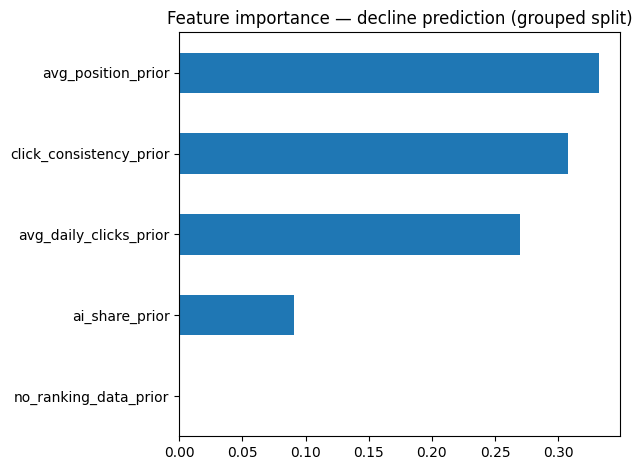

In [3]:
import json, os
os.makedirs('work/outputs', exist_ok=True)
os.makedirs('work/figures', exist_ok=True)

metrics = {
    'baseline_precision_at_50': 0.860, 'baseline_precision_at_50_grouped_test': 0.64,
    'model_precision_at_50_grouped': 0.740, 'model_precision_at_50_random_split': 1.000,
    'test_base_rate': float(y.iloc[test_idx].mean()), 'eligible_n': int(len(eligible)),
    'feature_importances': dict(zip(feature_cols, model.feature_importances_.tolist())),
}
with open('work/outputs/w07_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)

import matplotlib.pyplot as plt
fig, ax = plt.subplots()
pd.Series(model.feature_importances_, index=feature_cols).sort_values().plot.barh(ax=ax)
ax.set_title('Feature importance — decline prediction (grouped split)')
plt.tight_layout()
plt.savefig('work/figures/feature_importance.png', dpi=150)
print('exports written: work/outputs/w07_metrics.json, work/figures/feature_importance.png')

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.